# Multivariate linear regression

In this notebook, we will apply linear regression to (real) experimental data relating mix design variables to the compressive strength of high-performance concrete.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
def parity_plot(y_true, y_pred, title="Parity Plot"):
    plt.figure()
    
    # Scatter plot
    #plt.scatter(y_true, y_pred, s=80, c='k', marker='x', linewidth=0.7, zorder=1)
    plt.hexbin(y_true, y_pred, zorder=-1, cmap='gray_r', vmin=1, gridsize=12, edgecolors='none')
    # Perfect prediction line (y = x)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'goldenrod', linewidth=1.5, zorder=1, linestyle='--')
    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    # Labels and title
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(title)

    mse = np.mean((y_true - y_pred)**2)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    
    plt.text(min_val, max_val, f"MSE = {mse:.3f}\nR² = {r2:.3f}",
             verticalalignment='top')
    
    plt.show()

In [62]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)

# Separate inputs (X) and output (y)
X = df.iloc[1:, :-1].values   # all columns except last (except the title row)
y = df.iloc[1:, -1].values    # last column (except the title row)

## Aggiungere normalizzazione dati

Estimated parameters:
[-2.65126027e+01  1.19863467e-01  1.04671747e-01  8.86785204e-02
 -1.43614505e-01  3.04759303e-01  1.88913454e-02  2.15163196e-02
  1.14397709e-01]


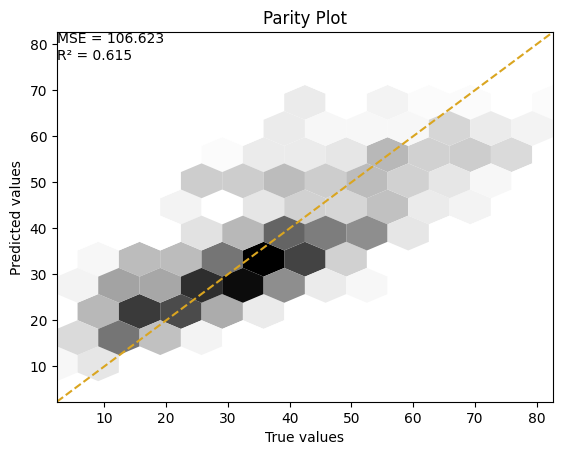

In [64]:
# Add bias term (column of ones)
N = X.shape[0]
X_design = np.hstack([np.ones((N, 1)), X])

# Compute least-squares solution
beta = np.linalg.pinv(X_design) @ y
print("Estimated parameters:")
print(beta)

# Predictions
y_pred = X_design @ beta

# Visualization
parity_plot(y, y_pred)

In [65]:
## More compact option using scikit-learn

Intercept: -26.512602691587716
Coefficients: [ 0.11986347  0.10467175  0.08867852 -0.1436145   0.3047593   0.01889135
  0.02151632  0.11439771]


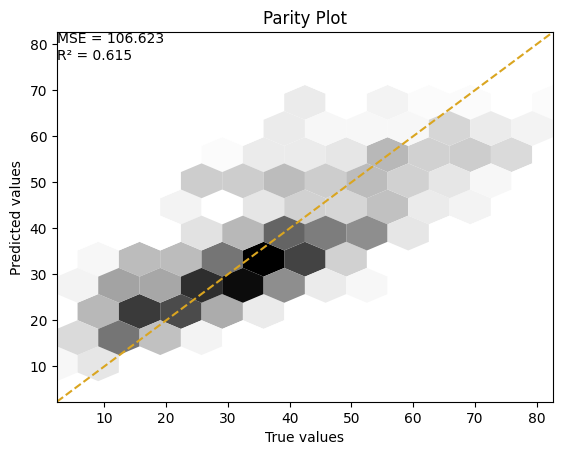

In [66]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred = model.predict(X)
parity_plot(y, y_pred)

## Results Interpretation:

#### What can we conclude about the performance of a linear regression model?